#  Llama-3 8b [TPU Train]

Learning to train llms on tpu, Hope this will help you too!

Prerequisite: Access to using llama-3

Please upvote if you learn or find this helpful!

# Import libs 

In [1]:
# ---------------------------------------------------------------------------
# Kaggle TPU VM v5e-8 環境安裝
#
# 重點:絕對不要 pip install / uninstall torch、torch_xla、torchvision、torchaudio。
# Kaggle 的 v5e-8 image 內建的 torch + torch_xla + libtpu 是互相配對好的;
# 舊 notebook 那組 torch~=2.1.0 / torch_xla[tpu]~=2.1.0 的 libtpu 早於 v5e 硬體,
# 初始化時會在 C++ 層直接 abort,結果就是「沒有 traceback 的 kernel died」。
#
# -qq 只是 pip 的安靜度旗標,跟裝哪個版本無關,但它會把版本衝突警告一起吞掉,
# 所以這裡一律降成 -q。
# ---------------------------------------------------------------------------

# peft 0.12 / accelerate 0.33 與 transformers 4.42 同期;原本釘的 0.6.0 / 0.24.1 是 2023 年的
!pip install -q "peft==0.12.0" "accelerate==0.33.0"

# Gemma-2 需要 transformers >= 4.42,這個 whl 就在 /kaggle/input 裡,離線可用、版本確定
!pip install -q /kaggle/input/models/google/gemma-2/transformers/gemma-2-9b-it/2/transformers/transformers-4.42.0.dev0-py3-none-any.whl

# bitsandbytes 只支援 CUDA,在 TPU 上沒有意義
!pip uninstall -q bitsandbytes -y

# 不然 TensorFlow 會先搶走 TPU,PyTorch 拿不到權限
!pip uninstall -q tensorflow -y

!pip install -q -U "numpy<2.8"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.10.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.10.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
google-metrax 0.2.4 requires numpy>=2.1.3, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
scipy 1.18.0 requires numpy<2.8,>=2.0.0, but you have numpy 1.26.4 which is incompatible.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.5.3 which is incompatible.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
%%writefile spmd_util.py
import torch
import torch.nn as nn
import re
import torch_xla.core.xla_model as xm

try:
    # torch_xla >= 2.2 (the only path that exists in >= 2.5)
    import torch_xla.distributed.spmd as xs
except ImportError:  # torch_xla <= 2.1
    import torch_xla.experimental.xla_sharding as xs

from transformers import (
    GPTNeoXConfig, T5Config, LlamaConfig
)

try:
    from transformers import Gemma2Config
except ImportError:  # transformers < 4.42 has no Gemma-2
    Gemma2Config = None

# ends with $ to prevent sharding lora parameters
GPTNEOX_RULES = (
    # embeddings
    ("gpt_neox\\.embed_in", ("mp", "fsdp")),
    # atention
    ("attention\\.query_key_value$", ("fsdp", "mp")),
    ("attention\\.dense$", ("mp", "fsdp")),
    # mlp
    ("mlp\\.dense_h_to_4h$", ("fsdp", "mp")),
    ("mlp\\.dense_4h_to_h$", ("mp", "fsdp")),
    # output
    ("embed_out", ("fsdp", "mp")),
)

T5_RULES = (
    # embeddings
    ("shared$", ("mp", "fsdp")),
    ("embed_tokens$", ("mp", "fsdp")),
    
    # attention
    ("q$", ("fsdp", "mp")),
    ("k$", ("fsdp", "mp")),
    ("v$", ("fsdp", "mp")),
    ("o$", ("mp", "fsdp")),

    # mlp
    ("w$", ("fsdp", "mp")),
    ("wi_0$", ("fsdp", "mp")),
    ("wi_1$", ("fsdp", "mp")),
    ("wo$", ("mp", "fsdp")),

    # seq2seq lm head
    ("lm_head", ("fsdp", "mp")),
)

LLAMA_RULES = (
    ("model\\.embed_tokens$", ("mp", "fsdp")),
    ("self_attn\\.(q_proj|k_proj|v_proj)$", ("fsdp", "mp")),
    ("self_attn\\.o_proj$", ("mp", "fsdp")),
    ("mlp\\.gate_proj$", ("fsdp", "mp")),
    ("mlp\\.down_proj$", ("mp", "fsdp")),
    ("mlp\\.up_proj$", ("fsdp", "mp")),
    ("lm_head$", ("fsdp", "mp")),
    )
    
GEMMA2_RULES = LLAMA_RULES

ALL_RULES = [
    (GPTNeoXConfig, GPTNEOX_RULES),
    (T5Config, T5_RULES),
    (LlamaConfig, LLAMA_RULES),
]

if Gemma2Config is not None:
    ALL_RULES.append((Gemma2Config, GEMMA2_RULES))

def find_rule(model):
    for config, rule in ALL_RULES:
        if model.config.__class__ == config:
            return rule
    raise Exception("unsupported model to partitioning")

strkey2id = {
    "dp": 0,
    "fsdp": 1,
    "mp": 2
}

# peft 會把被 LoRA 包住的層改成 lora.Linear 包裝層(它不是 nn.Linear 的子類別),
# 真正的 nn.Linear 被搬到 <path>.base_layer。上面的規則都以 $ 結尾,
# 所以必須先把這個後綴拿掉才比對得到主權重 —— 否則被 LoRA 包住的層
# 會完全不被切分,而是複製到每一個 TPU chip 上(Gemma-2 掛滿 7 層時 = 每 chip 多 16.6 GB)。
# lora_A / lora_B 的名稱不帶這個後綴,仍然會被 $ 擋掉,維持複製(這是正確的行為)。
BASE_LAYER_SUFFIX = ".base_layer"


def strip_base_layer(name):
    if name.endswith(BASE_LAYER_SUFFIX):
        return name[: -len(BASE_LAYER_SUFFIX)]
    return name


def partition_module(model, mesh, device=None, verbose=False):
    device = device if device is not None else xm.xla_device()
    partition_specs = find_rule(model)
    rule = [(k, tuple([strkey2id[x] for x in v])) for k, v in partition_specs]

    n_sharded = 0
    for name, module in model.named_modules():
        module.to(device)
        if isinstance(module, (nn.Embedding, nn.Linear)):
            match_name = strip_base_layer(name)
            for rule_pattern, spec in rule:
                if re.findall(rule_pattern, match_name):
                    if verbose:
                        print("match", rule_pattern, name)

                    xs.mark_sharding(module.weight, mesh, spec)
                    n_sharded += 1
                    break

    print(f"partition_module: sharded {n_sharded} modules")
    return n_sharded


def partition_module_dp(model, mesh, device=None, verbose=False):
    device = device if device is not None else xm.xla_device()
    spec = (1, 2)

    n_sharded = 0
    for name, module in model.named_modules():
        module.to(device)
        if isinstance(module, (nn.Embedding, nn.Linear)):
            xs.mark_sharding(module.weight, mesh, spec)
            n_sharded += 1

    print(f"partition_module_dp: sharded {n_sharded} modules")
    return n_sharded

Writing spmd_util.py


In [6]:
# ---------------------------------------------------------------------------
# 環境診斷 — 這是整份 notebook 最重要的一格
# 先確認 image 給了什麼版本、TPU 看不看得到,再決定要不要動任何東西。
#
# PJRT_DEVICE 必須在 import torch_xla 之前設定。
# ---------------------------------------------------------------------------
import os
os.environ['PJRT_DEVICE'] = 'TPU'
# 告訴 transformers 不要使用 TensorFlow(cell 2 移除後殘留的空殼 tensorflow 會讓 tokenizer.decode 當掉)
os.environ['USE_TF'] = '0'

import importlib.metadata as md

import torch
import torch_xla
import torch_xla.runtime as xr

print('torch     :', torch.__version__)
print('torch_xla :', torch_xla.__version__)
for pkg in ['libtpu', 'libtpu-nightly', 'transformers', 'peft', 'accelerate']:
    try:
        print(f'{pkg:<16}:', md.version(pkg))
    except md.PackageNotFoundError:
        print(f'{pkg:<16}: (not installed)')

# # v5e-8 = 8 chips x 1 core = 8 個 device(v3-8 是 4 chips x 2 cores,也是 8 個)
print('devices   :', xr.global_runtime_device_count())


torch     : 2.8.0+cpu
torch_xla : 2.8.0
libtpu          : 0.0.17
libtpu-nightly  : (not installed)
transformers    : 4.42.0.dev0
peft            : 0.12.0
accelerate      : 0.33.0
devices   : 8


E0000 00:00:1790013995.401236      73 common_lib.cc:648] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:238


In [7]:
import os
import gc
import re
from time import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import transformers
from sklearn.metrics import accuracy_score, log_loss
# from transformers import AutoTokenizer, Gemma2ForSequenceClassification
from transformers import AutoTokenizer, LlamaForSequenceClassification
from peft import get_peft_model, LoraConfig, TaskType
import torch.nn.functional as F

import torch_xla
import torch_xla.core.xla_model as xm
import torch_xla.runtime as xr

# 必須在任何 xm.xla_device() 之前呼叫
xr.use_spmd()

# torch_xla.experimental.xla_sharding 在 2.5 起已被刪除,
# torch_xla.distributed.spmd 從 2.2 到 2.8 都存在且匯出名稱完全相同。
import torch_xla.distributed.spmd as xs
from torch_xla.distributed.spmd import Mesh, XLAShardedTensor

# spmd_util 內已註冊 Gemma2 的切分規則(與 Llama 命名相同,直接沿用 LLAMA_RULES)
from spmd_util import partition_module

tqdm.pandas()

print(f'Torch Version: {torch.__version__}')


Torch Version: 2.8.0+cpu


# Configs

In [ ]:
class CFG:
    NUM_EPOCHS = 1
    BATCH_SIZE = 8  # 必須是 TPU device 數(8)的倍數;每個 chip 分到 16/8 = 2 筆
    DROPOUT = 0.05
    MODEL_NAME = '/kaggle/input/models/metaresearch/llama-3/transformers/8b-chat-hf/1'
    SEED = 2024 
    # 每次實驗換一個 tag,權重檔不會互相覆蓋
    # Run 1 = 官方 55k + 外部 33k + 長度 1536 + 梯度裁剪 + 隨機就地 A/B 對調
    RUN_TAG = 'run1_33k_len1536'
    MAX_GRAD_NORM = 1.0  # 梯度裁剪上限;bf16 + LoRA scaling=2 時是防 nan 的必要保險

    MAX_LENGTH = 1536  # 1024 時驗證集有 20.6% 被截斷,且未截斷樣本的 log loss 明顯較好
    # NUM_WARMUP_STEPS = 128
    LR_MAX = 5e-5 
    NUM_LABELS = 3 
    LORA_RANK = 16   # 第一輪是 4
    LORA_ALPHA = 32  # 維持 alpha = 2 x rank 的比例
    # Gemma-2 每層 7 個投影層:attention 的 q/k/v/o + MLP 的 gate/up/down。
    # Run 2 要用的是「六模組」版本 —— 刻意不含 down_proj:
    #   gate/up 吃 3584 維 hidden(residual 本來就存著)→ 掛 LoRA 幾乎不增加記憶體。
    #   down   吃 14336 維中間層(4 倍大)→ 42 層全部留下來,1536 下約 14.8GB,實測會 OOM。
    #   OOM 是記憶體問題,梯度裁剪救不了;實測 down_proj OOM、gate+up 只有 nan(裁剪可解)。
    # LORA_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj']
    LORA_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj']
    # LOG_EVERY = 100  # 每幾步印一次「這一段」的平均 loss / accuracy
    
DEVICE = xm.xla_device() # Initialize TPU Device

/tmp/ipykernel_73/835921914.py:31: DeprecationWarning: Use torch_xla.device instead
  DEVICE = xm.xla_device() # Initialize TPU Device


In [11]:
def set_seeds(seed):
    """Set seeds for reproducibility """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    # Set seed for all TPU cores
    xm.set_rng_state(seed, device=xm.xla_device())  

set_seeds(seed=CFG.SEED)

/tmp/ipykernel_73/1015508229.py:12: DeprecationWarning: Use torch_xla.device instead
  xm.set_rng_state(seed, device=xm.xla_device())


# Tokenizer

In [12]:
tokenizer = AutoTokenizer.from_pretrained(CFG.MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'
tokenizer.add_eos_token = True

# save tokenizer to load offline during inference
tokenizer.save_pretrained('tokenizer')

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


('tokenizer/tokenizer_config.json',
 'tokenizer/special_tokens_map.json',
 'tokenizer/tokenizer.json')

In [13]:
# Utility function giving token length
def get_token_lengths(texts):
    # tokenize and receive input_ids for reach text
    input_ids = tokenizer(texts.tolist(), return_tensors='np')['input_ids']
    # return length of inputs_ids for each text
    return [len(t) for t in input_ids]

# Prepare train


In [14]:
train = pd.read_csv('/kaggle/input/competitions/llm-classification-finetuning/train.csv')
def process(input_str):
    stripped_str = input_str.strip('[]')
    sentences = [s.strip('"') for s in stripped_str.split('","')]
    return  ' '.join(sentences)

train.loc[:, 'prompt'] = train['prompt'].apply(process)
train.loc[:, 'response_a'] = train['response_a'].apply(process)
train.loc[:, 'response_b'] = train['response_b'].apply(process)

# Drop 'Null' for training
indexes = train[(train.response_a == 'null') & (train.response_b == 'null')].index
train.drop(indexes, inplace=True)
train.reset_index(inplace=True, drop=True)

print(f"Total {len(indexes)} Null response rows dropped")
print('Total train samples: ', len(train))

Total 19 Null response rows dropped
Total train samples:  57458


In [16]:
#Validation split
from sklearn.model_selection import train_test_split

label_for_split = train[['winner_model_a','winner_model_b','winner_tie']].idxmax(axis=1)
train, valid = train_test_split(
    train, test_size=0.1, random_state=CFG.SEED, stratify=label_for_split)
train = train.reset_index(drop=True)
valid = valid.reset_index(drop=True)

print(f'Train: {len(train)}, Valid: {len(valid)}')

Train: 51712, Valid: 5746


In [19]:
# ---- 外部資料:LMSYS Additional 33k(只加進 train,valid 維持官方切分不變) ----
# 不再做 A/B 對調增強:推論端已有 TTA 處理順序偏差,重複一份資料只會讓 step 數加倍。
# 改成加入真正不重疊的外部樣本,同樣的訓練時間換到更高的樣本多樣性。
import os

COLS = ['prompt', 'response_a', 'response_b',
        'winner_model_a', 'winner_model_b', 'winner_tie']

# 這個資料集底下有兩個 csv,必須用 deduplicated 那份:
#   lmsys-33k.csv              → 有 28.8% 的 prompt 與官方 train 重疊。
#                                我們的 valid 是從官方 train 切出來的,用它等於讓模型
#                                在訓練時看過驗證集的題目,驗證分數會虛假變好。
#   lmsys-33k-deduplicated.csv → 與官方 prompt 重疊 0%,這份才能用。
EXTRA_CSV = ('/kaggle/input/datasets/abdullahmeda/lmsys-additional-33k-labelled-conversations/lmsys-33k-deduplicated.csv')
assert os.path.exists(EXTRA_CSV), f'找不到 {EXTRA_CSV};請確認資料集已掛載且檔名正確'
extra = pd.read_csv(EXTRA_CSV)
missing = [c for c in COLS if c not in extra.columns]
assert not missing, f'外部資料集缺少欄位 {missing};實際欄位 {list(extra.columns)}'

# 與官方 train 完全相同的前處理
for col in ['prompt', 'response_a', 'response_b']:
    extra[col] = extra[col].astype(str).apply(process)
n_before = len(extra)
extra = extra[~((extra.response_a == 'null') & (extra.response_b == 'null'))]
extra = extra[COLS].reset_index(drop=True)
print(f'extra: {n_before} -> {len(extra)}(去掉 null response)')

# 去掉與 valid 重疊的樣本,避免驗證集被污染
fingerprint = lambda df: df['prompt'] + '||' + df['response_a'] + '||' + df['response_b']
# 兩道去重:
# (1) 三欄指紋 —— 避免同一筆樣本被計入兩次而變相加權。
# (2) 只比 prompt 且只對 valid —— 「同題目、不同回答」仍算洩漏,驗證分數會虛假變好。
#     deduplicated 版本理論上兩者都是 0,這裡是保險,真的是 0 就不會動到任何一筆。
seen = set(fingerprint(valid)) | set(fingerprint(train))
dup_row = fingerprint(extra).isin(seen)
dup_prompt = extra['prompt'].isin(set(valid['prompt']))
dup = dup_row | dup_prompt
print(f'extra 去重:整筆重複 {int(dup_row.sum())} 筆, 與 valid 同 prompt {int(dup_prompt.sum())} 筆, '
      f'共移除 {int(dup.sum())} 筆')
extra = extra[~dup].reset_index(drop=True)

train = pd.concat([train[COLS], extra], ignore_index=True)
# 打散,避免同來源的樣本連續成批
train = train.sample(frac=1.0, random_state=CFG.SEED).reset_index(drop=True)
print(f'Train after adding extra 33k: {len(train)}')

# ---- 消除 A/B 位置偏差:隨機「就地」對調一半樣本 ----
# 不是複製一份對調的資料(那會讓樣本數翻倍、step 數翻倍,在 1536 下會超過 9 小時上限),
# 而是每一筆有 50% 機率把 A/B 互換(標籤跟著換)。模型看到的 A/B 分佈一樣是對稱的,
# 位置偏差一樣被消除,但 step 數完全不變 —— 成本為零。
# 只對 train 做;valid 必須保持原樣,才能和歷史結果比較。
rng = np.random.RandomState(CFG.SEED)
flip = rng.rand(len(train)) < 0.5
train.loc[flip, ['response_a', 'response_b']] = (
    train.loc[flip, ['response_b', 'response_a']].values)
train.loc[flip, ['winner_model_a', 'winner_model_b']] = (
    train.loc[flip, ['winner_model_b', 'winner_model_a']].values)
print(f'隨機就地對調 {int(flip.sum())} / {len(train)} 筆(winner_tie 不受影響)')
print('對調後三類比例:', train[['winner_model_a','winner_model_b','winner_tie']].mean().round(4).to_dict())

# ---- 分段截斷:prompt / A / B 各自分配額度,保證 A、B 都看得到(推論 notebook 必須用同一份) ----
PROMPT_MAX = 256   # 需要截斷時,prompt 最多保留幾個 token
SAFETY = 8         # decode→encode 可能差幾個 token,留一點餘裕
TEMPLATE = ('User prompt: ', '\n\nModel A :\n', '\n\n--------\n\nModel B:\n')

def build_text(prompt, resp_first, resp_second):
    return TEMPLATE[0] + prompt + TEMPLATE[1] + resp_first + TEMPLATE[2] + resp_second

def allocate(len_a, len_b, budget):
    """A、B 平分 budget;短的一方用不完的額度讓給另一方"""
    half = budget // 2
    if len_a <= half:
        return len_a, min(len_b, budget - len_a)
    if len_b <= half:
        return min(len_a, budget - len_b), len_b
    return half, budget - half

def build_texts_truncated(prompts, first, second):
    """回傳 (texts, needs_trunc);needs_trunc[i] = 這筆原本是否超過長度"""
    enc = lambda s: tokenizer(list(s), add_special_tokens=False)['input_ids']
    overhead = len(tokenizer(''.join(TEMPLATE), add_special_tokens=False)['input_ids']) + 2  # + bos, eos
    budget = CFG.MAX_LENGTH - overhead - SAFETY
    texts, needs_trunc = [], []
    for p_txt, a_txt, b_txt, p, a, b in zip(prompts, first, second,
                                            enc(prompts), enc(first), enc(second)):
        if len(p) + len(a) + len(b) <= budget:  # 不需截斷:原文不動
            texts.append(build_text(p_txt, a_txt, b_txt))
            needs_trunc.append(False)
            continue
        p = p[:PROMPT_MAX]  # prompt 保留開頭(多輪對話時和回答的開頭對得上)
        na, nb = allocate(len(a), len(b), budget - len(p))
        texts.append(build_text(tokenizer.decode(p), tokenizer.decode(a[:na]), tokenizer.decode(b[:nb])))
        needs_trunc.append(True)
    return texts, np.array(needs_trunc)

# train = 官方 55k 的 90% + 外部 33k,其中約一半已隨機對調 A/B
train['text'], train_trunc = build_texts_truncated(train['prompt'], train['response_a'], train['response_b'])
valid['text'], valid_trunc = build_texts_truncated(valid['prompt'], valid['response_a'], valid['response_b'])
print(f'需要截斷的比例: train {train_trunc.mean():.1%}, valid {valid_trunc.mean():.1%}')
print(train['text'][4])
print(valid['text'][4])

extra: 21187 -> 21187(去掉 null response)


extra 去重:整筆重複 0 筆, 與 valid 同 prompt 0 筆, 共移除 0 筆
Train after adding extra 33k: 72899
隨機就地對調 36400 / 72899 筆(winner_tie 不受影響)
對調後三類比例: {'winner_model_a': 0.354, 'winner_model_b': 0.3479, 'winner_tie': 0.2981}


/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:88: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


需要截斷的比例: train 7.2%, valid 8.5%
User prompt: how does my RSPS clients and login background work in this GitHub repository? https://github.com/plong95/Valius-Client

Model A :
I'm sorry, but I cannot access the specific GitHub repository that you have linked without additional information. Please provide more details about your question, such as what you mean by \"RSPS clients and login background,\" so I can better assist you.

--------

Model B:
As the repository owner, I can tell you that the repository is a client for the Reddit Simple Proxy Service (RSPS).\n\nRSPS is a free and open-source service that allows developers to create custom clients for the Reddit website and its various subsites (such as /r/IAmA and /r/news). These clients can be used to access and interact with the Reddit platform, including posting comments, voting on posts, and following users.\n\nIn the Valius client repository, you can find code that implements the functionality of the Valius client, which is a po

In [20]:
# # Train with only take 50% train dataset
# train = train[:int(len(train) * 0.5)]

train.loc[:, 'token_count'] = get_token_lengths(train['text'])

# prepare label for model
train.loc[:, 'label'] = np.argmax(train[['winner_model_a','winner_model_b','winner_tie']].values, axis=1)

# Display data
display(train.head())

,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie,text,token_count,label
0,Plurigrid Protocol is a protocol for decentral...,Plurigrids form a network of generative channe...,channels can be used in Plurigrid to model the...,1,0,0,User prompt: Plurigrid Protocol is a protocol ...,495,0
1,explain to me how 1 and 0 could be at the same...,In the context of digital electronics and comp...,In the context of computer science or digital ...,1,0,0,User prompt: explain to me how 1 and 0 could b...,718,0
2,Write opening paragraph for a new book about a...,"In the history of science, few questions have ...","\""For centuries, scientists and philosophers h...",0,1,0,User prompt: Write opening paragraph for a new...,356,1
3,"Tell me a haiku about love, a black cat and a ...","Love, black cat, starry night\n\nFurry paws up...","A haiku about love, a black cat, and a starry ...",0,1,0,"User prompt: Tell me a haiku about love, a bla...",106,1
4,how does my RSPS clients and login background ...,"I'm sorry, but I cannot access the specific Gi...","As the repository owner, I can tell you that t...",0,0,1,User prompt: how does my RSPS clients and logi...,338,2


# Tokenize

In [24]:
# Tokenize Data
tokens = tokenizer(
    train['text'].tolist(), 
    padding='max_length', 
    max_length=CFG.MAX_LENGTH, 
    truncation=True, 
    return_tensors='np')

# Input IDs are the token IDs
INPUT_IDS = tokens['input_ids']
# Attention Masks to Ignore Padding Tokens
ATTENTION_MASKS = tokens['attention_mask']
# Label of Texts
LABELS = train[['winner_model_a','winner_model_b','winner_tie']].values


valid_tokens = tokenizer(
    valid['text'].tolist(),
    padding='max_length',
    max_length=CFG.MAX_LENGTH,
    truncation=True,
    return_tensors='np')

VALID_INPUT_IDS = valid_tokens['input_ids']
VALID_ATTENTION_MASKS = valid_tokens['attention_mask']
VALID_LABELS = valid[['winner_model_a','winner_model_b','winner_tie']].values

print(f'INPUT_IDS shape: {INPUT_IDS.shape}, ATTENTION_MASKS shape: {ATTENTION_MASKS.shape}')
print(f'LABELS shape: {LABELS.shape}')

INPUT_IDS shape: (72899, 1536), ATTENTION_MASKS shape: (72899, 1536)
LABELS shape: (72899, 3)


In [26]:
def train_dataset(batch_size):
    N_SAMPLES = LABELS.shape[0]
    IDXS = np.arange(N_SAMPLES - (N_SAMPLES % batch_size))
    while True:
        # Shuffle Indices
        np.random.shuffle(IDXS)
        # Iterate Over All Indices Once
        for idxs in IDXS.reshape(-1, batch_size):
            input_ids = torch.tensor(INPUT_IDS[idxs]).to(DEVICE)
            attention_mask = torch.tensor(ATTENTION_MASKS[idxs]).to(DEVICE)
            labels = torch.tensor(LABELS[idxs]).to(DEVICE)  # Multi-label output
            
            # Shard Over TPU Nodes if applicable (you need to define mesh appropriately)
            xs.mark_sharding(input_ids, mesh, DATA_SHARDING)
            xs.mark_sharding(attention_mask, mesh, DATA_SHARDING)
            xs.mark_sharding(labels, mesh, DATA_SHARDING)
            
            yield input_ids, attention_mask, labels

TRAIN_DATASET = train_dataset(CFG.BATCH_SIZE)

# Load Model

In [ ]:
# Load model for classification with 3 target label
base_model = LlamaForSequenceClassification.from_pretrained(
    CFG.MODEL_NAME,
    num_labels=CFG.NUM_LABELS,
    torch_dtype=torch.bfloat16)


base_model.config.pretraining_tp = 1 

# Assign Padding TOKEN
base_model.config.pad_token_id = tokenizer.pad_token_id

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at /kaggle/input/models/metaresearch/llama-3/transformers/8b-chat-hf/1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Low-Rank Adaptation [LORA]

In [28]:
lora_config = LoraConfig(
    r=CFG.LORA_RANK,  # the dimension of the low-rank matrices
    lora_alpha = CFG.LORA_ALPHA, # scaling factor for LoRA activations vs pre-trained weight activations
    lora_dropout= CFG.DROPOUT, 
    bias='none',
    inference_mode=False,
    task_type=TaskType.SEQ_CLS,
    target_modules=CFG.LORA_MODULES ) # Only Use Output and Values Projection

In [29]:
# Create LoRa Model
model = get_peft_model(base_model, lora_config)
# Trainable Parameters
model.print_trainable_parameters()


if CFG.GRADIENT_CHECKPOINTING:
    model.enable_input_require_grads()  # 沒有這行,checkpointing 下 LoRA 拿不到梯度
    model.gradient_checkpointing_enable()
    print('gradient checkpointing: ON(記憶體換速度)')

trainable params: 32,518,144 || all params: 7,537,455,104 || trainable%: 0.4314


In [32]:
# Number of TPU Nodes
num_devices = xr.global_runtime_device_count()
mesh_shape = (1, num_devices, 1)
device_ids = np.array(range(num_devices))
mesh = Mesh(device_ids, mesh_shape, ('dp', 'fsdp', 'mp'))

# 資料的切分規格:batch 維度 -> mesh 第 1 軸 'fsdp'(大小 = num_devices),序列維度不切。
# 原本用 (0, 1) 會把 batch 對到大小為 1 的 'dp' 軸,等於每個 TPU chip 都在算完整 batch,
# 權重有切但 activation 沒切 -> Gemma-2 第一個 step 就 HBM OOM。ㄥㄥㄥ
DATA_SHARDING = (1, None)
assert CFG.BATCH_SIZE % num_devices == 0, (
    f'BATCH_SIZE={CFG.BATCH_SIZE} 必須是 num_devices={num_devices} 的倍數,batch 才能平均分到每個 chip')
# distribute model
partition_module(model, mesh)

print(f'num_devices: {num_devices}')

# ---------------------------------------------------------------------------
# 切分稽核:直接問每個權重的 sharding 標註,比從記憶體反推精確。
#   '{devices=[1,8]0,1,...}' -> 有切分,每個 chip 只放 1/8
#   ''(空字串) 或 '{replicated}' -> 沒切分,每個 chip 各存一份完整副本
# ---------------------------------------------------------------------------
if hasattr(torch_xla, 'sync'):
    torch_xla.sync()   # torch_xla >= 2.6 的新名字,取代 xm.mark_step()
else:
    xm.mark_step()

sharded_n = unsharded_n = 0
sharded_bytes = unsharded_bytes = 0
unsharded_list = []
for _name, _p in model.named_parameters():
    _spec = torch_xla._XLAC._get_xla_sharding_spec(_p)
    _bytes = _p.numel() * _p.element_size()
    if _spec.startswith('{devices='):
        sharded_n += _p.numel(); sharded_bytes += _bytes
    else:
        unsharded_n += _p.numel(); unsharded_bytes += _bytes
        unsharded_list.append((_bytes, _name))

per_chip = sharded_bytes / num_devices + unsharded_bytes
print(f'  已切分  : {sharded_n / 1e9:6.2f} B 參數 -> 每 chip {sharded_bytes / num_devices / 2**30:5.2f} GiB')
print(f'  未切分  : {unsharded_n / 1e9:6.2f} B 參數 -> 每 chip {unsharded_bytes / 2**30:5.2f} GiB (完整複製)')
print(f'  每 chip 權重合計 ≈ {per_chip / 2**30:.2f} GiB')
unsharded_list.sort(reverse=True)
print('  未切分之中最大的 5 個:')
for _bytes, _name in unsharded_list[:5]:
    print(f'    {_bytes / 2**20:8.1f} MiB  {_name}')

# SPMD 下 xm.get_memory_info() 預設查的是「虛擬裝置」(8 顆晶片的集合體),
# 會丟 MemoryInfo not supported for SPMD virtual device,必須指定實體晶片。
REAL_DEVICES = torch_xla._XLAC._xla_get_all_runtime_devices()

def hbm_usage():
    """回傳 (已用 GiB, 上限 GiB);查不到就回傳 nan,不讓診斷程式把訓練弄掛。"""
    try:
        _mi = xm.get_memory_info(REAL_DEVICES[0])
        return _mi['bytes_used'] / 2**30, _mi['bytes_limit'] / 2**30
    except Exception as _e:
        print(f'  (HBM 查詢失敗: {_e})')
        return float('nan'), float('nan')

_used, _limit = hbm_usage()
print(f'  HBM ({REAL_DEVICES[0]}): {_used:.2f} / {_limit:.2f} GiB')

# 判讀:權重全部切分時,每 chip 約 2.3~3 GiB。
# 若「未切分」那一行是好幾 GiB,代表規則沒命中,不要往下跑。
assert unsharded_bytes / 2**30 < 2.0, (
    f'有 {unsharded_bytes / 2**30:.2f} GiB 的權重沒被切分而是複製到每個 chip,'
    f'切分規則沒命中,繼續跑下去會 OOM')

partition_module: sharded 225 modules
num_devices: 8


  已切分  :   7.50 B 參數 -> 每 chip  1.75 GiB
  未切分  :   0.03 B 參數 -> 每 chip  0.12 GiB (完整複製)
  每 chip 權重合計 ≈ 1.87 GiB
  未切分之中最大的 5 個:
         0.9 MiB  base_model.model.model.layers.9.mlp.up_proj.lora_B.default.weight
         0.9 MiB  base_model.model.model.layers.9.mlp.gate_proj.lora_B.default.weight
         0.9 MiB  base_model.model.model.layers.8.mlp.up_proj.lora_B.default.weight
         0.9 MiB  base_model.model.model.layers.8.mlp.gate_proj.lora_B.default.weight
         0.9 MiB  base_model.model.model.layers.7.mlp.up_proj.lora_B.default.weight
  (HBM 查詢失敗: Expected one of cpu, cuda, ipu, xpu, mkldnn, opengl, opencl, ideep, hip, ve, fpga, maia, xla, lazy, vulkan, mps, meta, hpu, mtia, privateuseone device type at start of device string: TPU
Exception raised from parse_type at /pytorch/c10/core/Device.cpp:62 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::__cxx11::basic_string<char, std::char_traits<char>, std::allocator<char> >) + 0x80 (0x7e1dfc2a54d0

In [33]:
# Verfy The Trainable Layers
MODEL_LAYERS_ROWS = []
TRAINABLE_PARAMS = []
N_TRAINABLE_PARAMS = 0

for name, param in model.named_parameters():
    # Layer Parameter Count
    n_parameters = int(torch.prod(torch.tensor(param.shape)))
    # Only Trainable Layers
    if param.requires_grad:
        # Add Layer Information
        MODEL_LAYERS_ROWS.append({
            'param': n_parameters,
            'name': name,
            'dtype': param.data.dtype,
        })
        # Append Trainable Parameter
        TRAINABLE_PARAMS.append({ 'params': param })
        # Add Number Of Trainable Parameters"
        N_TRAINABLE_PARAMS += n_parameters
        
display(pd.DataFrame(MODEL_LAYERS_ROWS))

print(f"""
===============================
N_TRAINABLE_PARAMS: {N_TRAINABLE_PARAMS:,}
N_TRAINABLE_LAYERS: {len(TRAINABLE_PARAMS)}
===============================
""")

,param,name,dtype
0,65536,base_model.model.model.layers.0.self_attn.q_pr...,torch.float32
1,65536,base_model.model.model.layers.0.self_attn.q_pr...,torch.float32
2,65536,base_model.model.model.layers.0.self_attn.k_pr...,torch.float32
3,16384,base_model.model.model.layers.0.self_attn.k_pr...,torch.float32
4,65536,base_model.model.model.layers.0.self_attn.v_pr...,torch.float32
...,...,...,...
380,65536,base_model.model.model.layers.31.mlp.gate_proj...,torch.float32
381,229376,base_model.model.model.layers.31.mlp.gate_proj...,torch.float32
382,65536,base_model.model.model.layers.31.mlp.up_proj.l...,torch.float32
383,229376,base_model.model.model.layers.31.mlp.up_proj.l...,torch.float32



N_TRAINABLE_PARAMS: 32,518,144
N_TRAINABLE_LAYERS: 385



# Training

In [34]:
# LR & Optimizer
N_SAMPLES = len(train)
STEPS_PER_EPOCH = N_SAMPLES // CFG.BATCH_SIZE
NUM_WARMUP_STEPS = int(0.07 * STEPS_PER_EPOCH * CFG.NUM_EPOCHS)

OPTIMIZER = torch.optim.AdamW(model.parameters(), lr=CFG.LR_MAX)

# Cosine Learning Rate With Warmup
lr_scheduler = transformers.get_cosine_schedule_with_warmup(
    optimizer=OPTIMIZER,
    num_warmup_steps=NUM_WARMUP_STEPS,
    num_training_steps=STEPS_PER_EPOCH * CFG.NUM_EPOCHS)

print(f'BATCH_SIZE: {CFG.BATCH_SIZE}, N_SAMPLES: {N_SAMPLES}, STEPS_PER_EPOCH: {STEPS_PER_EPOCH}')

BATCH_SIZE: 8, N_SAMPLES: 72899, STEPS_PER_EPOCH: 9112


In [36]:
input_ids, attention_mask, labels = next(TRAIN_DATASET)

print(f'input_ids shape: {input_ids.shape}, dtype: {input_ids.dtype}')
print(f'attention_mask shape: {attention_mask.shape}, dtype: {attention_mask.dtype}')
print(f'labels shape: {labels.shape}, dtype: {labels.dtype}')

input_ids shape: torch.Size([8, 1536]), dtype: torch.int64
attention_mask shape: torch.Size([8, 1536]), dtype: torch.int64
labels shape: torch.Size([8, 3]), dtype: torch.int64


In [38]:
# Put Model In Train Mode
model.train()

# Loss Function, Cross Entropy
LOSS_FN = torch.nn.CrossEntropyLoss().to(dtype=torch.float32)

In [ ]:
st = time()
# 原本是 filterwarnings("error"):任何一個 warning 都會中斷訓練,
# 在編譯過好幾分鐘之後被一個 deprecation warning 砍掉非常不划算。
warnings.filterwarnings("ignore")
METRICS = {
    'loss': [],
    'accuracy': {'y_true': [], 'y_pred': [] }}


def evaluate(model, input_ids_arr, attention_mask_arr, labels_arr, batch_size):
    """回傳 (log loss, accuracy, 三類機率);機率的順序和 valid 的列一一對應"""
    model.eval()  # 切換成評估模式(關掉dropout等訓練專用行為)
    n = input_ids_arr.shape[0]
    all_probs = []
    with torch.no_grad():  # 評估時不需要算梯度,省記憶體、跑更快
        for start in range(0, n, batch_size):
            idxs = np.arange(start, start + batch_size)
            idxs = np.minimum(idxs, n - 1)  # 最後一批不足 batch_size 時,用最後一筆補滿(形狀固定,避免 XLA 重新編譯)
            input_ids = torch.tensor(input_ids_arr[idxs]).to(DEVICE)
            attention_mask = torch.tensor(attention_mask_arr[idxs]).to(DEVICE)
            xs.mark_sharding(input_ids, mesh, DATA_SHARDING)
            xs.mark_sharding(attention_mask, mesh, DATA_SHARDING)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.to(dtype=torch.float32)
            # 要算 log loss 就必須保留「三個類別的機率」,不能只留 argmax
            all_probs.append(F.softmax(logits, dim=-1).cpu().numpy())
            xm.mark_step()
    model.train()  # 評估完切回訓練模式
    probs = np.concatenate(all_probs)[:n]  # 去掉補滿用的重複列
    y_true = np.argmax(labels_arr, axis=1)
    return (log_loss(y_true, probs, labels=[0, 1, 2]),
            accuracy_score(y_true, probs.argmax(axis=1)),
            probs)

for epoch in tqdm(range(CFG.NUM_EPOCHS)):
    ste = time()
    for step in range(STEPS_PER_EPOCH):
        # Zero Out Gradients
        OPTIMIZER.zero_grad()
        
        # Get Batch
        input_ids, attention_mask, labels = next(TRAIN_DATASET)
        
        # Forward Pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
       
        # Logits Float32
        logits = outputs.logits.to(dtype=torch.float32)
        
        # Backward Pass
        loss = LOSS_FN(logits, labels.to(dtype=torch.float32))
        loss.backward()
        
        # 梯度裁剪:模型是 bf16(尾數只有 7 bits),LoRA scaling = alpha/rank = 2,
        # 一旦某個 batch 出現大梯度就會溢位成 inf,再一步全部變 nan。
        # 這是之前把 LoRA 掛到 MLP(up/down_proj)時 loss 變 nan 的直接原因。
        # 健康的訓練很少真的觸發裁剪,成本幾乎為零。
        grad_norm = torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], CFG.MAX_GRAD_NORM)
        
        # optimizer step
        OPTIMIZER.step()
        xm.mark_step()
        
        # Update Learning Rate Scheduler
        lr_scheduler.step()
        
        # Update Metrics And Progress Bar
        METRICS['loss'].append(float(loss))
        METRICS['accuracy']['y_true'] += labels.squeeze().tolist()
        METRICS['accuracy']['y_pred'] += torch.argmax(F.softmax(logits, dim=-1), dim=1).cpu().tolist()
        
        if (step + 1) % 200 == 0:  
            metrics = 'µ_loss: {:.3f}'.format(np.mean(METRICS['loss']))
            metrics += ', step_loss: {:.3f}'.format(METRICS['loss'][-1])
            metrics += ', grad_norm: {:.2f}'.format(float(grad_norm))
            metrics += ', µ_auc: {:.3f}'.format(accuracy_score(torch.argmax(torch.tensor(METRICS['accuracy']['y_true']), axis=-1), \
                                                               METRICS['accuracy']['y_pred']))
            lr = OPTIMIZER.param_groups[0]['lr']
            print(f'{epoch+1:02}/{CFG.NUM_EPOCHS:02} | {step+1:04}/{STEPS_PER_EPOCH} lr: {lr:.2E}, {metrics}', end='')
            print(f'\nSteps per epoch: {step+1} complete | Time elapsed: {time()- st}')
            
        if (step + 1) % 1000 == 0:
            xm.save({k: v.cpu() for k, v in model.named_parameters() if v.requires_grad}, f'model_{CFG.RUN_TAG}_ckpt_step{step+1}.pth')
            print(f'Checkpoint saved at step {step+1}')
    
    print(f'\nEpoch {epoch+1} Completed | Total time for epoch: {time() - ste} ' )
    # 先存權重:就算後面的驗證出錯,訓練成果也已經保住
    xm.save({k: v.cpu() for k, v in model.named_parameters() if v.requires_grad}, f'model_llama_3_{CFG.RUN_TAG}_cp_{epoch+1}.pth')
    xm.save(OPTIMIZER.state_dict(), f'optimizer_llama_3_{CFG.RUN_TAG}_cp_{epoch+1}.pth')
    print(f'Model saved at epoch {epoch+1}| Elapsed time: {time() - st} ')

    # 再驗證:失敗只印訊息,不中斷 notebook
    try:
        valid_loss, valid_acc, valid_probs = evaluate(
            model, VALID_INPUT_IDS, VALID_ATTENTION_MASKS, VALID_LABELS, CFG.BATCH_SIZE)
        np.save(f'valid_probs_llama_{CFG.RUN_TAG}.npy', valid_probs)  # 之後算 ensemble 權重用(未做 TTA)
        print(f'Epoch {epoch+1} Validation log loss: {valid_loss:.5f} | accuracy: {valid_acc:.4f}')
    except Exception as e:
        print(f'驗證失敗(權重已存好,不影響): {type(e).__name__}: {e}')


  0%|          | 0/1 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


01/01 | 0200/9112 lr: 1.57E-05, µ_loss: 1.856, step_loss: 1.127, grad_norm: 33.52, µ_auc: 0.336
Steps per epoch: 200 complete | Time elapsed: 555.7675099372864


01/01 | 0400/9112 lr: 3.14E-05, µ_loss: 1.580, step_loss: 1.340, grad_norm: 40.73, µ_auc: 0.361
Steps per epoch: 400 complete | Time elapsed: 888.0219213962555


01/01 | 0600/9112 lr: 4.71E-05, µ_loss: 1.448, step_loss: 1.594, grad_norm: 54.49, µ_auc: 0.372
Steps per epoch: 600 complete | Time elapsed: 1218.9706482887268


...

01/01 | 9000/9112 lr: 2.15E-08, µ_loss: 0.973, step_loss: 0.814, grad_norm: 34.87, µ_auc: 0.540
Steps per epoch: 9000 complete | Time elapsed: 15483.599945545197


Checkpoint saved at step 9000



Epoch 1 Completed | Total time for epoch: 15674.298773765564 


Model saved at epoch 1| Elapsed time: 15681.87411737442 


Epoch 1 Validation log loss: 0.91423 | accuracy: 0.5687


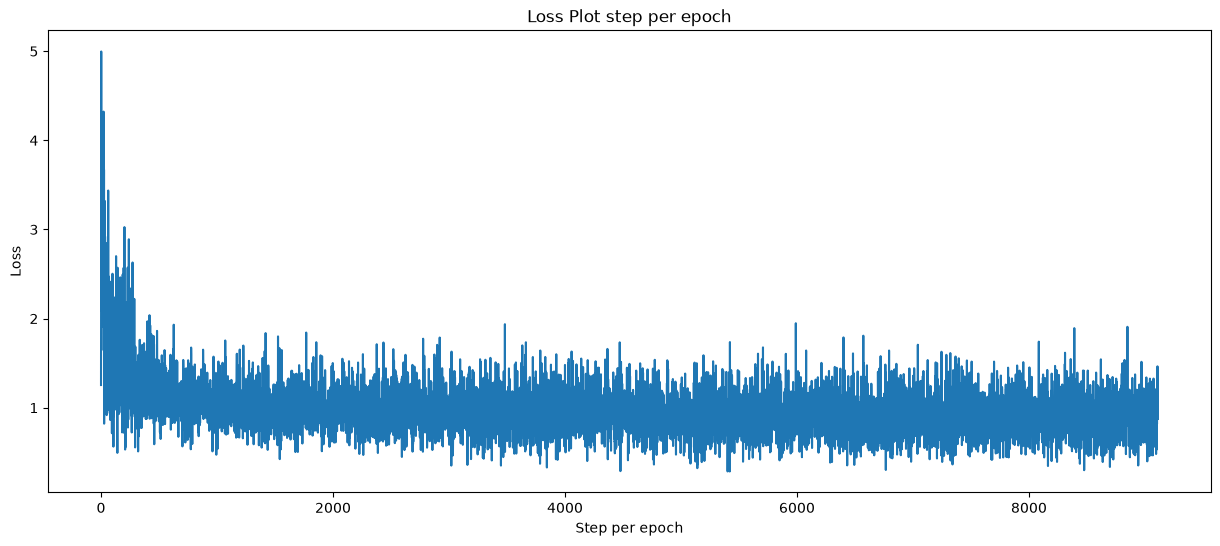

In [45]:
plt.figure(figsize=(15, 6))
plt.plot(METRICS['loss'])    
plt.xlabel('Step per epoch')
plt.ylabel('Loss')
plt.title('Loss Plot step per epoch')    
plt.show()

# Save Model


In [47]:
model = model.cpu()
torch.save(dict([(k,v) for k, v in model.named_parameters() if v.requires_grad]), 'llama_3_finetuned_model.pth')

# Conclusion 

There is still alot of room to speed up and optimize training! Try out more data, different batch size, lr... All the best!